# Movie Sentiment Analysis

Dataset link : https://ai.stanford.edu/~amaas/data/sentiment/

Kaggle Dataset link : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [29]:
# Import pandas to load and work with tabular data.
import pandas as pd

In [30]:
# Load the IMDb review dataset from the local data folder into a DataFrame.
url_path = "data/IMDB Dataset.csv"
df_original = pd.read_csv(url_path)

In [31]:
# Make a deep copy so later cleaning steps do not modify the original data.
df = df_original.copy(deep=True)

# Basic Info

In [32]:
# Show the column names so we can see what features are available in the dataset.
print(df.columns.to_list())

['review', 'sentiment']


In [33]:
# Preview the first few rows to quickly inspect the structure and sample content.
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [34]:
# Print a concise summary of the dataframe, including column dtypes and missing values.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [35]:
# Show basic descriptive statistics for the numeric fields in the dataset.
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [36]:
# Compute the number of duplicate rows by subtracting the count of unique rows from the full row count.
50000 - 49582 # no of duplicate rows

418

In [38]:
# Count how many reviews belong to each sentiment class.
# whether there is any data imbalance in the dataset.
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Descriptive Stats

In [39]:
# Import visualization libraries for plotting charts and distributions.
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Create new features that measure review length in characters and words.
# The lambda function splits the review text on whitespace to count words.
df['review_char_len'] = df['review'].apply(len)
df['review_word_len'] = df['review'].apply(lambda x: len(x.split()))

# Print descriptive statistics for the new length features.
print(df[['review_char_len','review_word_len']].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


In [41]:
# This cell is a note for exploring whether very short or very long reviews are linked to sentiment.
# It is a placeholder for a possible follow-up analysis.

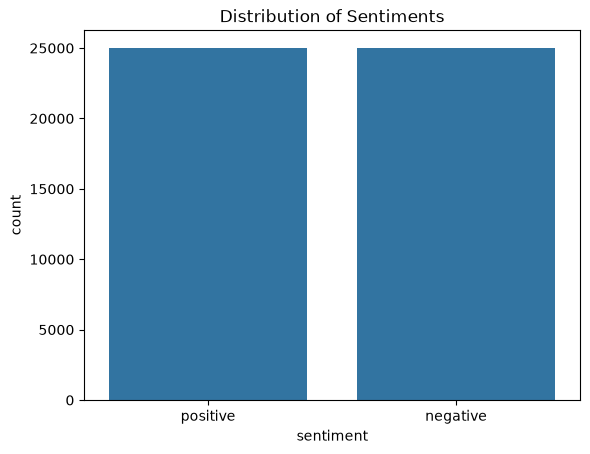

In [42]:
# Plot the sentiment distribution to see whether the classes are balanced.
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

A **KDE (Kernel Density Estimation) plot** is a data visualization tool used to show the distribution of a continuous variable. It acts like a smooth, continuous version of a histogram.

Instead of sorting data into jagged boxes (bins), a KDE plot uses a mathematical function to estimate a smooth probability density curve over your data points.

## The Intuition: Think of a Melting Chocolate Curve

Imagine you have a few data points scattered along a line.

1. If you place a small, smooth bell curve (a "Kernel") directly on top of every single data point.
2. Where data points are packed tightly together, those individual mini-curves overlap and stack up high.
3. Where data points are isolated, the curves remain low and flat.
4. If you add the heights of all these individual mini-curves together, you get one single, fluid, flowing line.

That final smooth line is your KDE plot. The y-axis represents the **Probability Density**, meaning the relative likelihood that a data value will fall in that specific range.

## Key Parameters: The Dial You Can Turn

The shape of a KDE plot depends heavily on one vital mathematical parameter: the **Bandwidth ($h$)**.

The bandwidth controls how wide or narrow those individual mini-bell-curves are. It essentially acts as a smoothing knob:

- **Too Low (Under-smoothed):** If your bandwidth is too small, the curve becomes overly jagged. It tries too hard to fit every single individual data point, capturing noise instead of the true pattern.
- **Too High (Over-smoothed):** If your bandwidth is too large, the curve becomes a giant, smooth, generic blob. It washes away real structure, like double peaks (bimodality).

## Why Use a KDE Plot Instead of a Histogram?

| Feature | Histogram | KDE Plot |
| --- | --- | --- |
| **Appearance** | Blocky, discrete bars | Smooth, continuous curve |
| **Sensitivity** | Heavily dependent on bin count and bin alignment. Changing bin size can drastically change the graph's look. | Smoothly adjusts based on bandwidth, making it less prone to arbitrary boundary cutoffs. |
| **Overlapping Distributions** | Hard to look at when overlaying multiple categories (the bars block each other). | Excellent for comparing groups. You can cleanly overlay multiple colored lines on top of each other. |

## Pitfalls to Watch Out For

While beautiful, KDE plots have one dangerous illusion: **The Boundary Leak**.

Because the mathematical kernel functions smooth out towards infinity, a KDE plot can show a curve dipping into impossible territories. For example, if you plot a dataset of "Customer Ages" (which cannot go below zero), a KDE plot might naturally smooth the curve backward, showing a small probability density for people aged -5. When using KDEs in practice, data scientists often have to explicitly truncate or clip the boundaries to match reality.

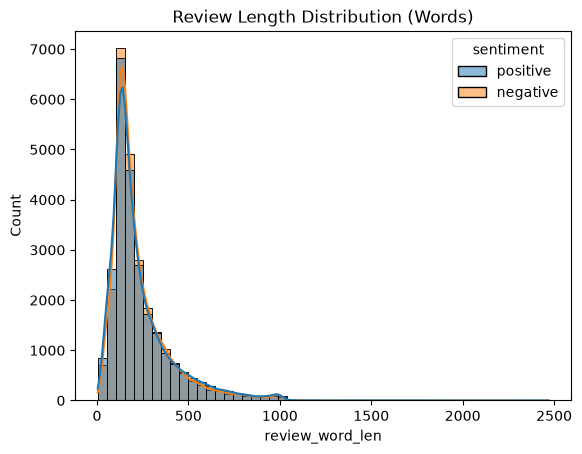

In [43]:
# Plot a histogram of review lengths with separate colors for each sentiment class.
sns.histplot(data=df, x='review_word_len', bins=50, hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

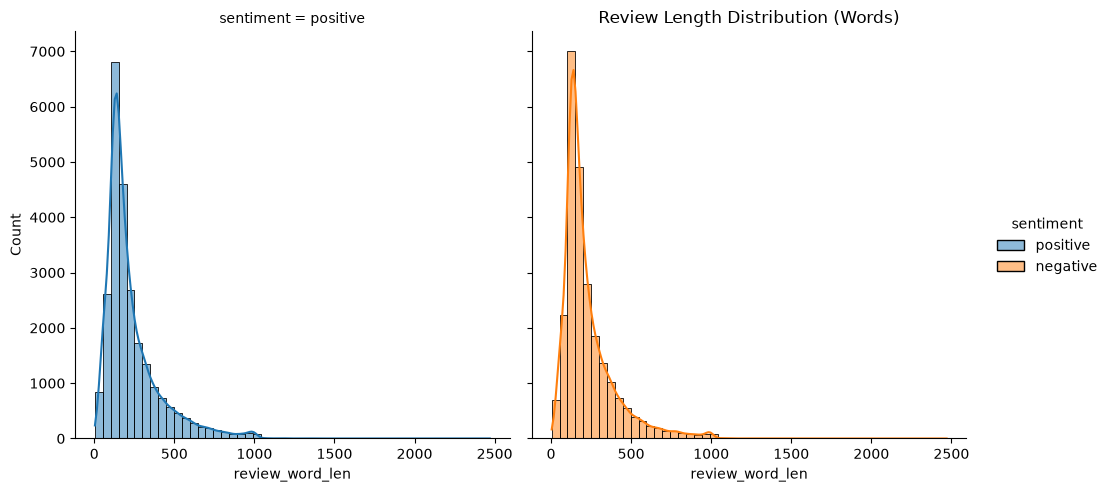

In [44]:
# Create faceted histograms so each sentiment class is shown in its own subplot.
sns.displot(data=df, x='review_word_len', bins=50, col="sentiment", hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

A **Box Plot** (also called a Box-and-Whisker Plot) is a standardized way of displaying the distribution of data based on a **five-number summary**: minimum, first quartile (Q1), median, third quartile (Q3), and maximum.

While a KDE plot shows you the smooth shape of data, a box plot gives you an immediate, precise summary of its statistics and outliers.

## Anatomy of a Box Plot

To interpret a box plot, you just need to understand its 5 main geometric parts:

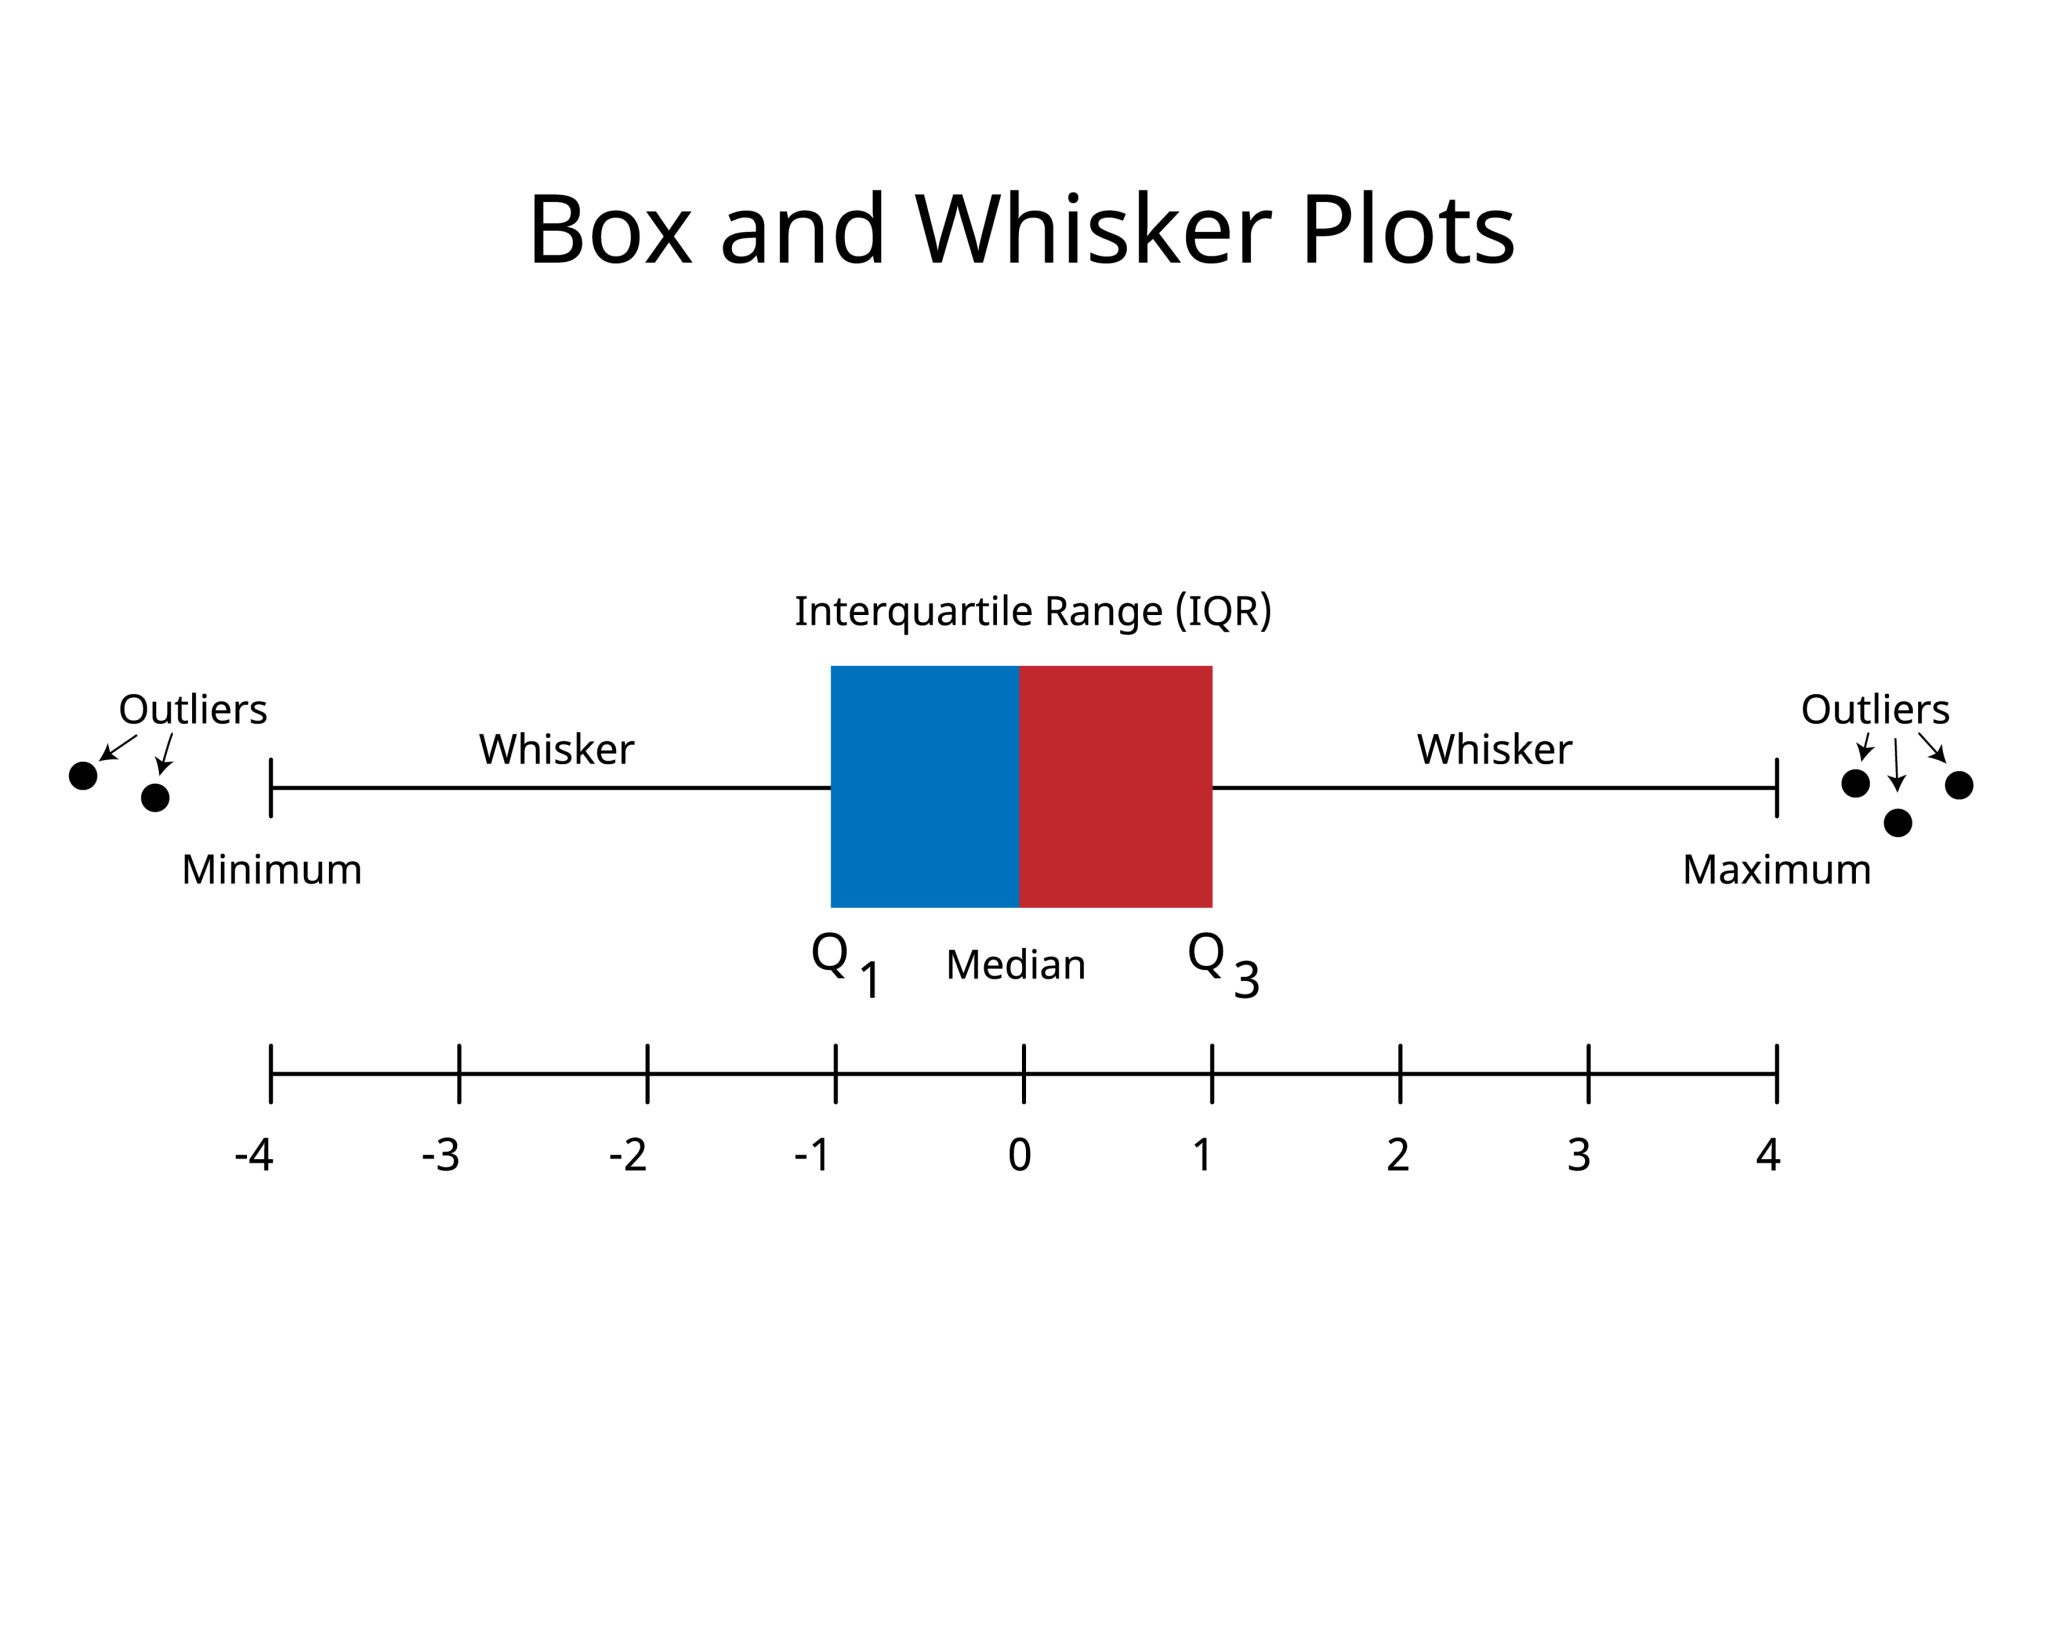

1. **The Median (The Center Line):** The line splitting the box in two represents the median (50th percentile) of the data. Half of the data points fall below this line, and half fall above it.
2. **The Box (Interquartile Range - IQR):** The main body of the plot represents the middle 50% of your data.
- **Bottom/Left Edge (Q1):** The 25th percentile. 25% of the data falls below this point.
- **Top/Right Edge (Q3):** The 75th percentile. 75% of the data falls below this point.
- **The Height/Length of the Box:** Calculated as $\text{IQR} = \text{Q3} - \text{Q1}$. A taller box means the middle 50% of your data is highly spread out.
3. **The Whiskers (The T-Bars):** The lines extending from the box show the range of the rest of the data. They extend to the minimum and maximum data values that are *not* considered outliers.
4. **Outliers (The Individual Dots):** Any data point that sits further away than $1.5 \times \text{IQR}$ from the edges of the box is mathematically classified as an outlier and drawn as an individual dot.

## How to Read and Interpret It

When you look at a box plot, train your eyes to scan for three distinct things:

### 1. Where is the center? (The Median)

Look at the median line to compare different groups. If you are comparing salaries across two departments and Department A's median line is significantly higher than Department B's, Department A generally earns more.

### 2. How spread out is the data? (The Dispersion)

- Look at the size of the box (IQR). A tightly squeezed box means the data points are very consistent and close to each other.
- Look at the total length of the whiskers. Long whiskers show high overall variance in your dataset.

### 3. Is the data skewed? (The Symmetry)

A box plot instantly reveals if your data is skewed without needing a histogram:

- **Symmetric:** If the median line sits perfectly in the middle of the box, and the whiskers are roughly equal in length, your data follows a normal, symmetric distribution.
- **Positive (Right) Skew:** If the median line is closer to the bottom/left of the box, and the top/right whisker is much longer, your data is right-skewed (meaning you have a long tail of exceptionally high values, like housing prices or incomes).
- **Negative (Left) Skew:** If the median line is pushed toward the top/right of the box, and the bottom/left whisker is pulled long, your data is left-skewed.

## Why Data Scientists Love Box Plots

Box plots shine brightest when you need to **compare multiple groups side-by-side**.

If you try to overlay 5 different histograms or 5 different KDE plots on top of each other, the visual space becomes an unreadable, chaotic mess of overlapping lines and bars. With box plots, you can cleanly line up 5 or 10 groups next to each other on a single axis to instantly spot differences in medians, variances, and outlier patterns across categories.

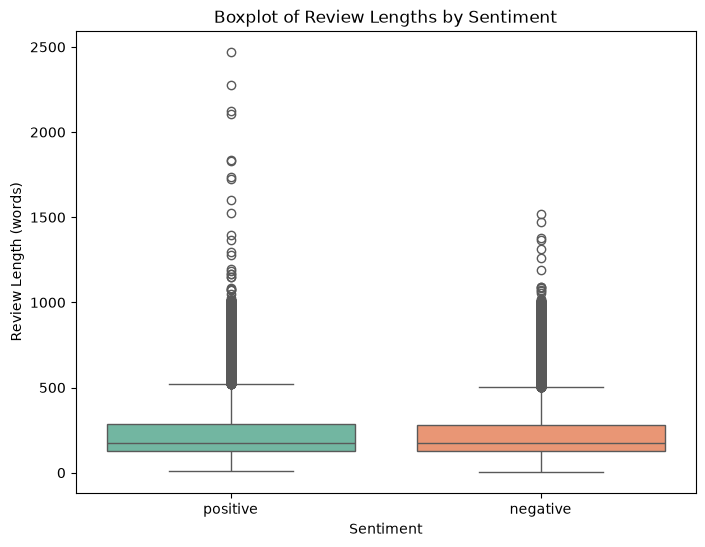

In [45]:
# Draw a boxplot to compare review length distributions across positive and negative sentiments.
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

# Removing outliers

In [46]:
# Import numpy for numerical operations used in the outlier analysis.
import numpy as np

In [47]:
# Calculate the first quartile, third quartile, and interquartile range for review length.
# These values are used to define the outlier thresholds.
Q1 = df['review_word_len'].quantile(0.25)
Q3 = df['review_word_len'].quantile(0.75)
IQR = Q3 - Q1

In [48]:
# Define the lower and upper bounds for outlier detection using the 1.5 IQR rule.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -105.0
Upper Bound: 511.0


In [49]:
# Filter rows that fall outside the outlier thresholds and store them separately.
outliers = df[(df['review_word_len'] < lower_bound) | (df['review_word_len'] > upper_bound)]
# DF of outliers

In [50]:
# Print the number of rows identified as outliers.
print("Number of outliers:", outliers.shape[0])

Number of outliers: 3708


In [51]:
# This is a manual subtraction showing the difference between the full dataset size and the number of outliers.
50000-3708

46292

In [52]:
# Remove rows outside the valid IQR range to create a cleaner dataset for further analysis.
df_clean_from_iqr = df[(df['review_word_len'] >= lower_bound) & (df['review_word_len'] <= upper_bound)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


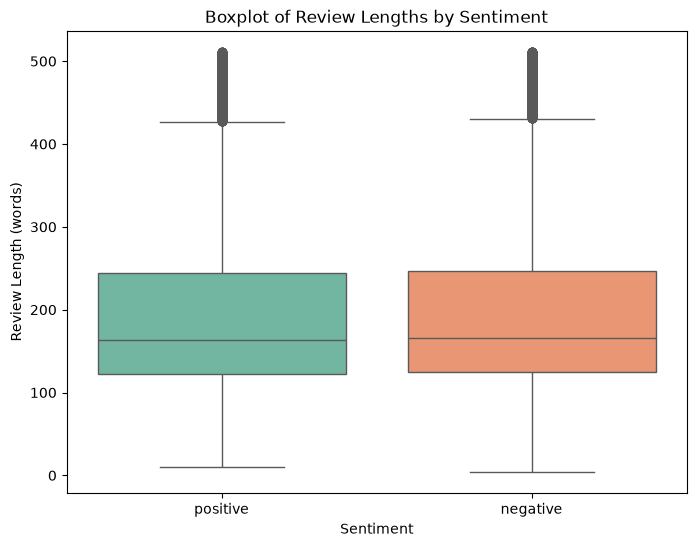

In [53]:
# Visualize the cleaned data to confirm the outlier removal improved the distribution.
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [54]:
# Preview the cleaned dataframe to confirm the filtered rows are in place.
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230
